In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import numpy as np

rx:  0.20199999999999996
ry:  0.20350000000000001
average xcoord:  1.7496341463414633
average y-coord:  1.7499512195121953


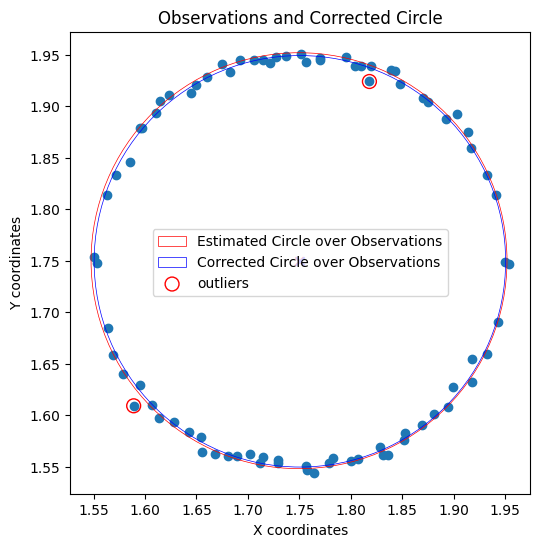

In [2]:
coords = pd.read_table('coordsXY_2026.txt', header=None)
#extract x and y coordinates
x = coords.iloc[:, 0]
y = coords.iloc[:, 1]
#calculate mean and range of x and y
xmean = np.mean(x)
xrange = np.max(x)-np.min(x)
rx = xrange/2
ymean = np.mean(y)
yrange = np.max(y)-np.min(y)
ry = yrange/2
mean = (xmean + ymean)/2
print("rx: ", rx)
print("ry: ", ry)
print("average xcoord: ", xmean)
print("average y-coord: ", ymean)
#plot
circle = patches.Circle(xy=(xmean, ymean), radius=rx, color='red', fill=False, linewidth=.5, label='Estimated Circle over Observations')
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y)
ax.add_patch(circle)
ax.scatter(xmean, ymean, color='red', marker='x')
#plot again with corrected radius
xhat = pd.read_table('xhat.txt', header=None).values.flatten()
ax.scatter(xhat[0], xhat[1], color='blue', marker='x')
circle2 = patches.Circle(xy=(xhat[0], xhat[1]), radius=xhat[2], color='blue', fill=False, linewidth=.5, label='Corrected Circle over Observations')
ax.add_patch(circle2)
outlier_pts = [56//2, 92//2]  # convert vector indices to point indices
ax.scatter(x[outlier_pts], y[outlier_pts], color='red', marker='o',s=100, facecolors='none', label='outliers')
ax.legend()
ax.set_aspect('equal')
ax.set_xlabel('X coordinates')
ax.set_ylabel('Y coordinates')
ax.set_title('Observations and Corrected Circle')
plt.show()


(82, 2)


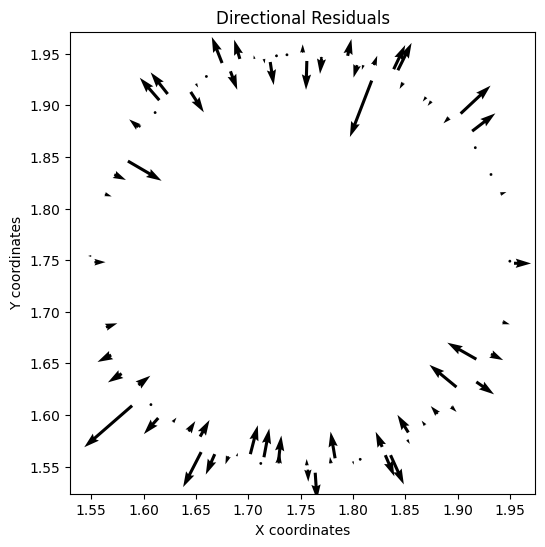

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
vhat = pd.read_table('vhat_coords.txt', header=None,sep=r'\s+').values
print(vhat.shape)
x_v = vhat[:,0]
y_v = vhat[:,1]
ax.quiver(x, y, x_v, y_v, scale=0.1)
ax.set_xlabel('X coordinates')
ax.set_ylabel('Y coordinates')
ax.set_title('Directional Residuals')
plt.show()

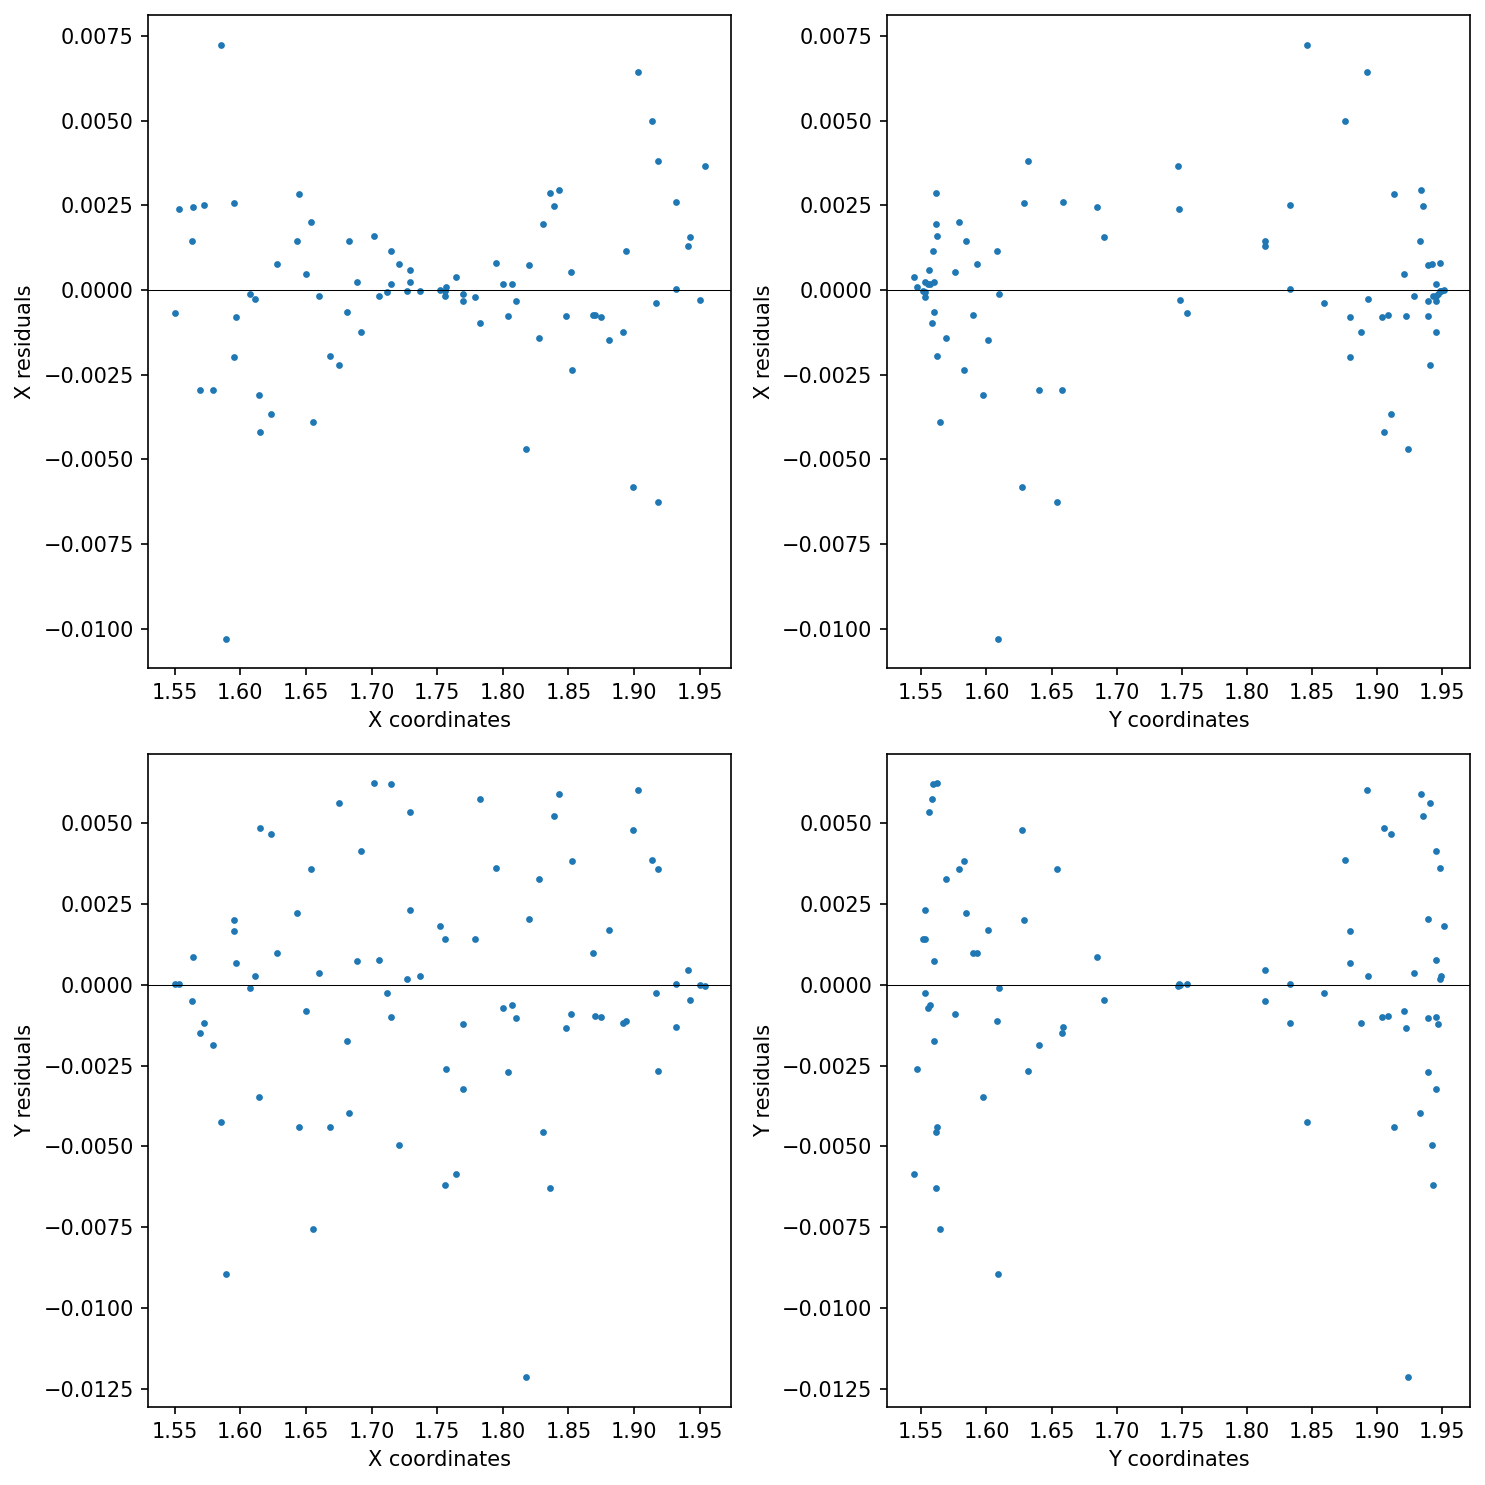

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=150)

axes[0,0].scatter(x, x_v, s=5)
axes[0,0].set_xlabel('X coordinates')
axes[0,0].set_ylabel('X residuals')

axes[0,1].scatter(y, x_v, s=5)
axes[0,1].set_xlabel('Y coordinates')
axes[0,1].set_ylabel('X residuals')

axes[1,0].scatter(x, y_v, s=5)
axes[1,0].set_xlabel('X coordinates')
axes[1,0].set_ylabel('Y residuals')

axes[1,1].scatter(y, y_v, s=5)
axes[1,1].set_xlabel('Y coordinates')
axes[1,1].set_ylabel('Y residuals')

for ax in axes.flatten():
    ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

In [17]:
from scipy import stats
n = vhat.shape[0]
print(f"n = {n}")
r = 2*n - 3
#r = n-3
sigma0_sq = 0.005**2
v = vhat.flatten()
sigma0_sq_hat = (v.transpose() @ v) / r
print(f"sigma0_sq_hat = {sigma0_sq_hat:.4e}")

T = r * sigma0_sq_hat / sigma0_sq
chi2_low  = stats.chi2.ppf(0.025, df=r)
chi2_high = stats.chi2.ppf(0.975, df=r)
print(f"T = {T:.4f}, critical: [{chi2_low:.4f}, {chi2_high:.4f}]")
print("Fail to reject H0" if chi2_low < T < chi2_high else "Reject H0")

n = 82
sigma0_sq_hat = 9.8863e-06
T = 63.6676, critical: [127.7605, 198.0247]
Reject H0


Number of bins: 13
Expected: [ 1  2  4  7 11 16 20 23 22 20 15 10  6]
Observed: [ 4  0  0  6  8 16 16 34 27 18 14 16  5]
Y = 30.7097, critical = 22.7418
Reject H0


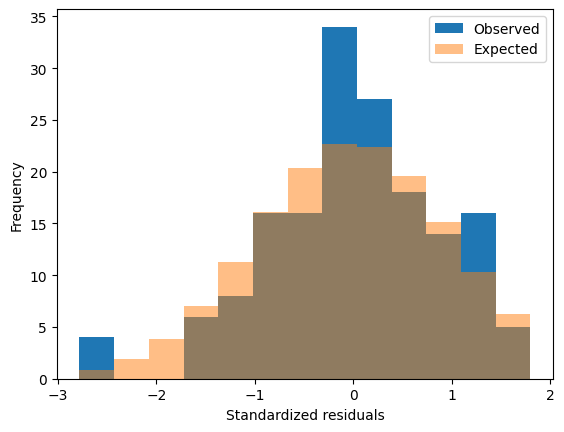

In [19]:
cvhat = pd.read_table('C_vhatdiag.txt', header=None).values.flatten()
w_i = v / cvhat
#determine number of bins
m = int(np.round(np.sqrt(len(w_i))))
print(f"Number of bins: {m}")
#Find left hand edges
O_k, edges = np.histogram(w_i, bins=m)
#deyermine expected values
E_k = []
for i in range(m):
    E_k.append(len(w_i) * (stats.norm.cdf(edges[i+1]) - stats.norm.cdf(edges[i])))
E_k = np.array(E_k)
#compare to actual values, rounded and converted to int for simplicity of comparison
print("Expected:", E_k.round(0).astype(int))
print("Observed:", O_k)

Y = np.sum((O_k - E_k)**2 / E_k)
df = m - 1
chi2_crit = stats.chi2.ppf(0.97, df=df)
print(f"Y = {Y:.4f}, critical = {chi2_crit:.4f}")
print("Reject H0" if Y > chi2_crit else "Fail to reject H0")
plt.bar(edges[:-1], O_k, width=np.diff(edges), align='edge', label='Observed')
plt.bar(edges[:-1], E_k, width=np.diff(edges), align='edge', alpha=0.5, label='Expected')
plt.legend()
plt.xlabel('Standardized residuals')
plt.ylabel('Frequency')
plt.show()

In [8]:
z_crit = stats.norm.ppf(0.995)
print(f"Critical value: {z_crit:.4f}")
outliers = np.where(np.abs(w_i) > z_crit)[0]
print(f"Outliers at indices: {outliers}")
print(f"w_i values: {w_i[outliers]}")

Critical value: 2.5758
Outliers at indices: [56 57 92 93]
w_i values: [-2.64848009 -2.64848004 -2.78120286 -2.78120287]
